In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os


import pyrootutils

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("TF_XLA_FLAGS", "--tf_xla_auto_jit=0")
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
import tensorflow as tf

tf.get_logger().setLevel('ERROR')

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)


2026-05-08 16:36:39.662155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 16:36:39.717477: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-08 16:36:39.717691: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
from building.scaling import (
    ScalingRunConfig,
    load_dataset_catalog,
    run_experiments,
    summarize_results,
    plot_summary,
)
from building.models import available_models, input_repr_for
print("Available models:", available_models())


In [ ]:
COLLECTION = "diff_genus"
N_SAMPLES = 20
EPOCHS = 50
PATIENCE = 10
BATCH_SIZE = 32
SEED = 42
THRESHOLD = 0.5

BUILD_MODEL = "sincnet"

MODELS_DIR = ROOT / "models" / BUILD_MODEL
RESULTS_FILE = MODELS_DIR / "results.jsonl"
print(f"{BUILD_MODEL} input_repr={input_repr_for(BUILD_MODEL)}")


In [ ]:
config = ScalingRunConfig(
    collection=COLLECTION,
    build_model=BUILD_MODEL,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    threshold=THRESHOLD,
    models_dir=MODELS_DIR,
    results_file=RESULTS_FILE,
)

catalog = load_dataset_catalog(collection=COLLECTION)

print(f"Loaded {len(catalog.class_names)} classes:")
print(catalog.class_names)


In [6]:

baseline_rows = run_experiments(
    catalog,
    config,
    run_baseline=True,
    run_scaling=False,
)
print(f"New baseline runs: {len(baseline_rows)}")
if baseline_rows:
    print("Last baseline row:")
    print(baseline_rows[-1])

[baseline] target=Carduelis_carduelis
[baseline] training_samples=2450 n_classes=2
Epoch 1/50


I0000 00:00:1778251017.427243    8472 service.cc:145] XLA service 0x716334006a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778251017.427316    8472 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1778251020.773552    8472 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


154/154 - 11s - 69ms/step - accuracy: 0.6643 - loss: 0.6448 - precision: 0.6708 - recall: 0.6388 - val_accuracy: 0.7229 - val_loss: 0.5815 - val_precision: 0.7229 - val_recall: 0.7229
Epoch 2/50


/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


154/154 - 2s - 13ms/step - accuracy: 0.7522 - loss: 0.5290 - precision: 0.7510 - recall: 0.7539 - val_accuracy: 0.7705 - val_loss: 0.5060 - val_precision: 0.7705 - val_recall: 0.7705
Epoch 3/50
154/154 - 2s - 12ms/step - accuracy: 0.7757 - loss: 0.4949 - precision: 0.7744 - recall: 0.7776 - val_accuracy: 0.7781 - val_loss: 0.4895 - val_precision: 0.7761 - val_recall: 0.7790
Epoch 4/50
154/154 - 2s - 12ms/step - accuracy: 0.7841 - loss: 0.4834 - precision: 0.7834 - recall: 0.7859 - val_accuracy: 0.7838 - val_loss: 0.4799 - val_precision: 0.7838 - val_recall: 0.7838
Epoch 5/50
154/154 - 2s - 12ms/step - accuracy: 0.7873 - loss: 0.4795 - precision: 0.7866 - recall: 0.7878 - val_accuracy: 0.8000 - val_loss: 0.4598 - val_precision: 0.8002 - val_recall: 0.8010
Epoch 6/50
154/154 - 2s - 12ms/step - accuracy: 0.7980 - loss: 0.4677 - precision: 0.7972 - recall: 0.7996 - val_accuracy: 0.8095 - val_loss: 0.4478 - val_precision: 0.8099 - val_recall: 0.8114
Epoch 7/50
154/154 - 2s - 11ms/step - acc

In [7]:
from building.scaling import print_baselines
print_baselines(catalog, RESULTS_FILE)

Target Class            | Precision |    Recall | Epochs | Timestamp
--------------------------------------------------------------------
'Carduelis_carduelis'   |    0.8375 ±    0.0154 |    0.8400 ±    0.0229 |    0.8383 ±    0.0037 |     27 
'Carpodacus_erythrinus' |    0.9205 ±    0.0196 |    0.9162 ±    0.0190 |    0.9179 ±    0.0002 |     50 
'Chloris_chloris'       |    0.7562 ±    0.0253 |    0.7486 ±    0.0533 |    0.7503 ±    0.0144 |     11 
'Fringilla_coelebs'     |    0.9064 ±    0.0231 |    0.9086 ±    0.0286 |    0.9068 ±    0.0027 |     35 
'Linaria_cannabina'     |    0.6363 ±    0.0215 |    0.6390 ±    0.0752 |    0.6340 ±    0.0268 |     12 
'Loxia_pytyopsittacus'  |    0.7224 ±    0.1301 |    0.6467 ±    0.2943 |    0.6128 ±    0.1142 |     12 
'Pyrrhula_pyrrhula'     |    0.7892 ±    0.1309 |    0.7295 ±    0.2248 |    0.7155 ±    0.0636 |     15 
'Serinus_serinus'       |    0.9166 ±    0.0158 |    0.9133 ±    0.0200 |    0.9146 ±    0.0021 |     13 
'Spinus_spinus

In [ ]:
scaling_rows = run_experiments(
    catalog,
    config=config,
    n_samples=N_SAMPLES,
    k_values=range(2, 6),
    run_baseline=False,
    run_scaling=True,
)
print(f"New scaling runs: {len(scaling_rows)}")
if scaling_rows:
    print("Last scaling row:")
    print(scaling_rows[-1])

[scaling] k=2 sample=1/20 chosen=['Carduelis_carduelis', 'Pyrrhula_pyrrhula'] extras_into_other=['Fringilla_coelebs', 'Carpodacus_erythrinus', 'Chloris_chloris', 'Serinus_serinus']
[scaling] training_samples=2450 n_classes=3
Epoch 1/50
230/230 - 13s - 58ms/step - accuracy: 0.4739 - loss: 0.5753 - precision: 0.7150 - recall: 0.1570 - val_accuracy: 0.4283 - val_loss: 0.5523 - val_precision: 0.3778 - val_recall: 0.2120
Epoch 2/50


/home/nathan/Documents/multi-chirp/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


230/230 - 4s - 17ms/step - accuracy: 0.6767 - loss: 0.4254 - precision: 0.7739 - recall: 0.5091 - val_accuracy: 0.5301 - val_loss: 0.5536 - val_precision: 0.5073 - val_recall: 0.3608
Epoch 3/50
230/230 - 4s - 16ms/step - accuracy: 0.7139 - loss: 0.4023 - precision: 0.7876 - recall: 0.5950 - val_accuracy: 0.5423 - val_loss: 0.5519 - val_precision: 0.5568 - val_recall: 0.4444
Epoch 4/50
230/230 - 3s - 14ms/step - accuracy: 0.7259 - loss: 0.3887 - precision: 0.7826 - recall: 0.6467 - val_accuracy: 0.5279 - val_loss: 0.5609 - val_precision: 0.5418 - val_recall: 0.4582
Epoch 5/50
230/230 - 3s - 14ms/step - accuracy: 0.7352 - loss: 0.3794 - precision: 0.7843 - recall: 0.6707 - val_accuracy: 0.5374 - val_loss: 0.5299 - val_precision: 0.5617 - val_recall: 0.4857
Epoch 6/50
230/230 - 3s - 15ms/step - accuracy: 0.7495 - loss: 0.3685 - precision: 0.7954 - recall: 0.6898 - val_accuracy: 0.5483 - val_loss: 0.5457 - val_precision: 0.5629 - val_recall: 0.4982
Epoch 7/50
230/230 - 4s - 16ms/step - acc

In [ ]:
baseline_metrics, summary_df = summarize_results(RESULTS_FILE)
print(f"Baseline recall: {baseline_metrics.recall:.4f}")
print(f"Baseline precision: {baseline_metrics.precision:.4f}")
summary_df

Baseline recall: 0.7437
Baseline precision: 0.7788


,k,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,top1_acc_mean,top1_acc_std,loss_mean,loss_std
0,2,0.494857,0.258262,0.623326,0.259074,0.552635,0.239044,0.612698,0.139277,0.489313,0.101460
1,3,0.300429,0.234706,0.623990,0.277651,0.401160,0.263134,0.497095,0.141349,0.448628,0.083239
2,4,0.219619,0.115181,0.522289,0.214177,0.351651,0.136522,0.454400,0.087031,0.408537,0.039748
3,5,0.114635,0.103920,0.526720,0.317321,0.283109,0.219012,0.322889,0.110654,0.412219,0.053318
4,6,0.041497,0.066779,0.286015,0.368865,0.125447,0.170567,0.234884,0.085068,0.409664,0.044181
5,7,0.044190,0.062968,0.276475,0.268231,0.162177,0.171365,0.207214,0.100260,0.383969,0.039361
6,8,0.019132,0.024524,0.337985,0.378389,0.144142,0.184767,0.171704,0.061811,0.368872,0.028381
7,9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.108971,0.019789,0.372711,0.017934


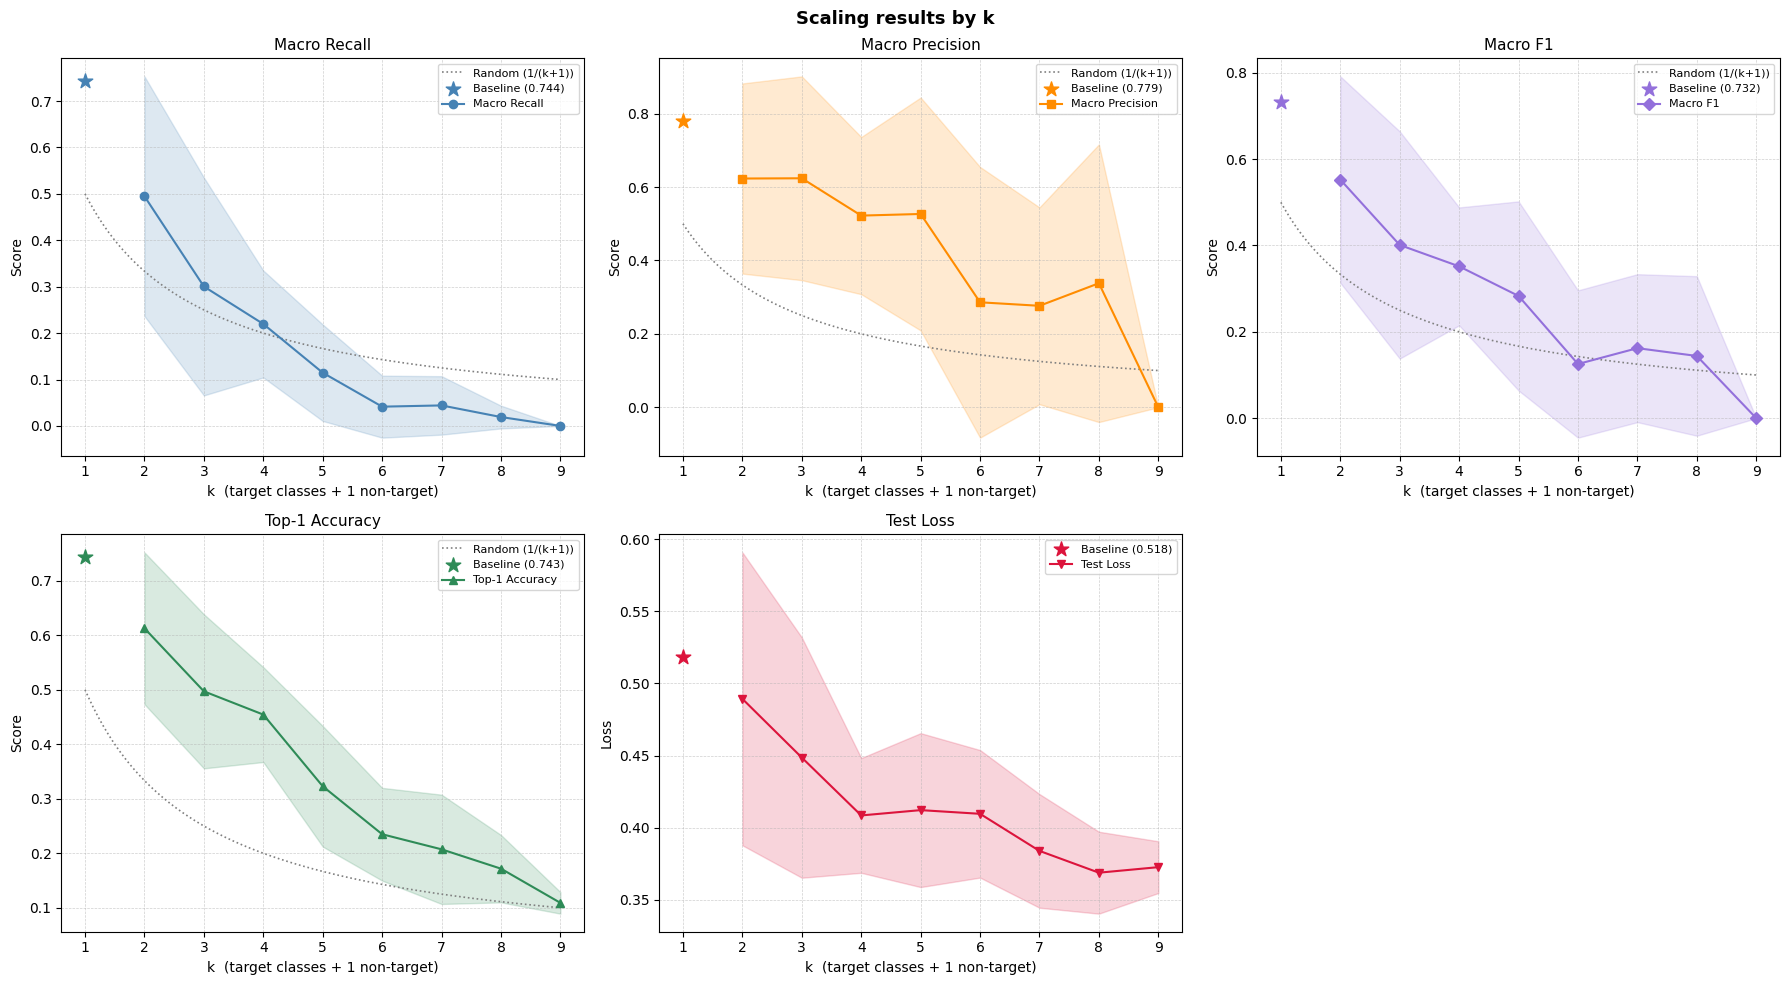

In [ ]:
plot_summary(summary_df, baseline=baseline_metrics)